
<b>¡Hola Juan Manuel!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


In [103]:
import pandas as pd

# Cargar los datasets
train = pd.read_csv("/datasets/gold_recovery_train.csv", parse_dates=['date'])
test = pd.read_csv("/datasets/gold_recovery_test.csv", parse_dates=['date'])
full = pd.read_csv("/datasets/gold_recovery_full.csv", parse_dates=['date'])


print(train.info())
print(test.info())
print(full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   date                                                16860 non-null  datetime64[ns]
 1   final.output.concentrate_ag                         16788 non-null  float64       
 2   final.output.concentrate_pb                         16788 non-null  float64       
 3   final.output.concentrate_sol                        16490 non-null  float64       
 4   final.output.concentrate_au                         16789 non-null  float64       
 5   final.output.recovery                               15339 non-null  float64       
 6   final.output.tail_ag                                16794 non-null  float64       
 7   final.output.tail_pb                                16677 non-null  float64       
 8   final.

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [103] es muy buena decisión cargar las tres fuentes (train/test/full) y ejecutar <code>info()</code> de inmediato. Esto te permite “auditar” el dataset antes de modelar: ver tipos, conteo de nulos y tamaños. En proyectos con datos industriales, esa revisión temprana evita que el modelo aprenda patrones raros solo porque una columna viene incompleta o con tipo incorrecto. Como mejora opcional, podrías acompañarlo con <code>head()</code> y un conteo de nulos por columna para identificar rápidamente las variables más afectadas.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
También en [103], usar <code>parse_dates=['date']</code> es un acierto clave: convierte la fecha desde el inicio y evita errores típicos al ordenar o hacer imputaciones temporales. En datasets de procesos, la variable tiempo suele ser el “hilo conductor” de la coherencia del análisis, y tenerla como <code>datetime</code> facilita validaciones como monotonía, gaps y cortes de periodo.
</div>

# Preprocesamiento de Datos y Observaciones Iniciales

### Estructura de los Datos

Tras cargar y examinar los datasets, se observa que el conjunto de entrenamiento contiene un mayor número de variables en comparación con el conjunto de prueba. Esta diferencia es esperada, ya que algunas de las variables presentes en el dataset de entrenamiento corresponden a parámetros de salida o a cálculos que no están disponibles en el momento de realizar predicciones.

Con el fin de garantizar consistencia entre los conjuntos de entrenamiento y prueba —y evitar problemas de *data leakage*— se procederá a restringir el dataset de entrenamiento únicamente a aquellas variables que también están presentes en el dataset de prueba. De este modo, el modelo será entrenado exclusivamente con información que estaría disponible en un escenario real.

### Manejo de Valores Ausentes

Durante el análisis preliminar, se identificó la presencia de valores ausentes en múltiples variables del dataset. Dado que estos valores pueden afectar negativamente el rendimiento y la estabilidad del modelo, es necesario tratarlos en la etapa de preprocesamiento.

Para abordar este problema, se realizará una imputación de los valores faltantes utilizando ffill ya que es mejor que  la mediana porque los datos son temporales y de procesos industriales. 

### Resumen de los Pasos de Preprocesamiento

- Alinear las variables del conjunto de entrenamiento con las del conjunto de prueba para evitar *data leakage*  
- Eliminar variables no disponibles o derivadas de información futura  
- Imputar valores ausentes utilizando la mediana de cada variable  

In [104]:

import numpy as np

def recovery_calc(C, F, T):
    return (C * (F - T)) / (F * (C - T)) * 100

calc = recovery_calc(
    train['rougher.output.concentrate_au'],
    train['rougher.input.feed_au'],
    train['rougher.output.tail_au']
)

mae = np.mean(abs(calc - train['rougher.output.recovery']))
print(mae)


9.303415616264301e-15


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [104] validaste la columna objetivo <code>rougher.output.recovery</code> recalculándola con la fórmula. Esta práctica es excelente: cuando un dataset trae una variable “calculada”, verificarla reduce el riesgo de entrenar sobre un target con errores de ingeniería o con una definición distinta a la que crees estar usando.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El MAE casi cero en [104] está muy bien interpretado: confirma consistencia numérica y que tu implementación respeta la definición de recuperación. Además, al usar una métrica simple como MAE aquí, haces la verificación muy transparente (cualquier lector entiende que “diferencia promedio” ~ 0 implica coincidencia). Como micro-sugerencia, podrías añadir una línea para revisar valores extremos (min/max) de la diferencia para detectar outliers puntuales.
</div>

In [105]:


train = train.fillna(method='ffill')
test = test.fillna(method='ffill')
full = full.fillna(method="ffill")



<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [105] aplicaste <code>ffill</code> para imputación, lo cual encaja muy bien con datos temporales de planta: muchas variables de sensores cambian de forma gradual y el “último valor conocido” suele ser una aproximación razonable cuando hay huecos cortos. Esta lógica es especialmente útil cuando los faltantes se deben a fallos de registro y no a cambios reales en el proceso.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Antes de usar <code>ffill</code> en [105], conviene asegurarse de que el DataFrame esté ordenado por <code>date</code>. Si el índice no está en orden temporal, el “forward fill” podría rellenar con valores de un momento incorrecto y eso sí afectaría la validez del modelo. Una solución simple sería ordenar: <code>train = train.sort_values('date')</code> (y lo mismo para test/full) justo antes de imputar.
</div>

El error absoluto medio (MAE) entre los valores calculados de recuperación y los valores proporcionados en el dataset es extremadamente bajo (≈ 9.3e-15), lo que indica que la fórmula ha sido implementada correctamente y que los datos son consistentes.

La pequeña diferencia observada se debe a limitaciones de precisión numérica en los cálculos con punto flotante, por lo que puede considerarse despreciable.

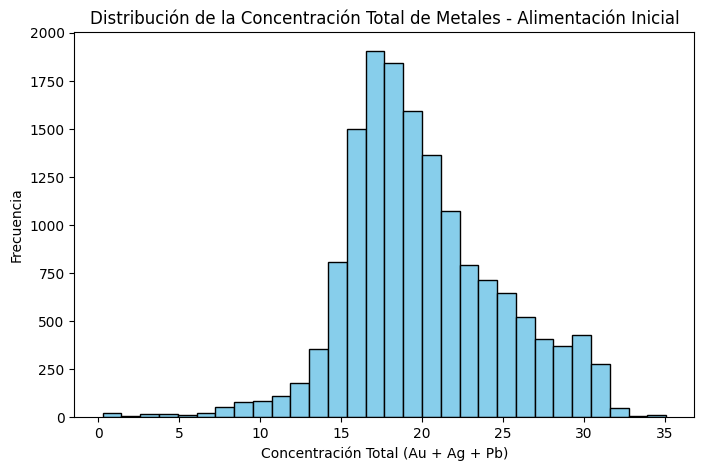

In [106]:
import matplotlib.pyplot as plt

# Calcular concentración total de metales en la alimentación
total_feed = (
    train['rougher.input.feed_au'] +
    train['rougher.input.feed_ag'] +
    train['rougher.input.feed_pb']
)

# Filtrar valores cercanos a cero
total_feed_filtered = total_feed[total_feed > 0.1]

# Graficar
plt.figure(figsize=(8,5))
plt.hist(total_feed_filtered, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Concentración Total de Metales - Alimentación Inicial')
plt.xlabel('Concentración Total (Au + Ag + Pb)')
plt.ylabel('Frecuencia')
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [106] calculas una “concentración total” (Au+Ag+Pb) y la exploras con histograma. Este tipo de variable agregada es muy didáctica: resume el comportamiento global del mineral y ayuda a detectar valores anómalos (por ejemplo, concentraciones cercanas a cero) sin revisar metal por metal. Es una buena forma de hacer control de calidad exploratorio.
</div>

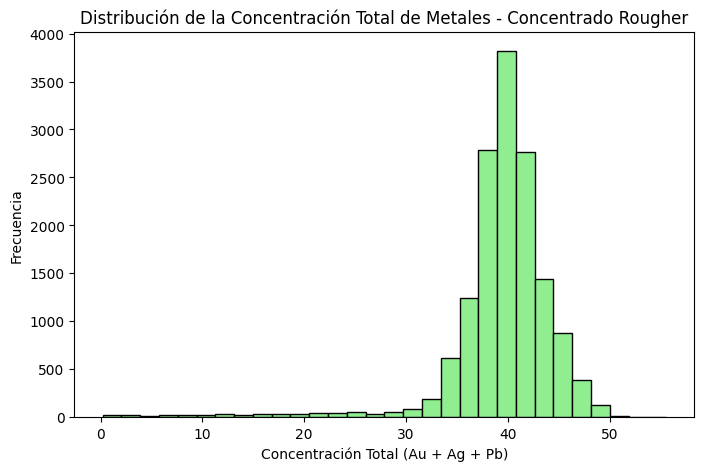

In [107]:
# Calcular concentración total de metales en el concentrado rougher
rougher_cols = ['rougher.output.concentrate_au', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb']

# Seleccionar solo las columnas que existen en train para evitar KeyError
cols_existentes = [col for col in rougher_cols if col in train.columns]

total_rougher = train[cols_existentes].sum(axis=1)

# Filtrar valores cercanos a cero
total_rougher_filtered = total_rougher[total_rougher > 0.1]

# Graficar
plt.figure(figsize=(8,5))
plt.hist(total_rougher_filtered, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribución de la Concentración Total de Metales - Concentrado Rougher')
plt.xlabel('Concentración Total (Au + Ag + Pb)')
plt.ylabel('Frecuencia')
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [107] me gusta el enfoque defensivo de construir <code>cols_existentes</code> para evitar <code>KeyError</code>. Esa práctica hace tu notebook más robusto (por ejemplo, si cambian columnas o si se reutiliza el código con otra versión del dataset). En proyectos reales, este tipo de validaciones ahorra mucho tiempo de depuración.
</div>

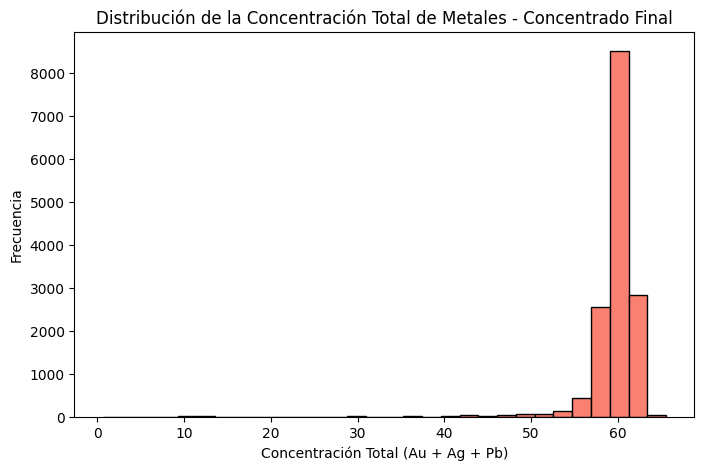

In [108]:
# Calcular concentración total de metales en el concentrado final
total_final = (
    train['final.output.concentrate_au'] +
    train['final.output.concentrate_ag'] +
    train['final.output.concentrate_pb']
)

# Filtrar valores cercanos a cero
total_final_filtered = total_final[total_final > 0.1]

# Graficar
plt.figure(figsize=(8,5))
plt.hist(total_final_filtered, bins=30, color='salmon', edgecolor='black')
plt.title('Distribución de la Concentración Total de Metales - Concentrado Final')
plt.xlabel('Concentración Total (Au + Ag + Pb)')
plt.ylabel('Frecuencia')
plt.show()


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [108] repites el análisis de distribución para el concentrado final. Comparar alimentación → rougher → final es justo la narrativa correcta para este problema: esperas que Au suba progresivamente y eso te permite validar que los datos “cuentan la historia” del proceso metalúrgico. Este tipo de EDA conecta dominio + datos, y eso suele mejorar mucho las decisiones de modelado.
</div>

Se eliminaron valores cercanos a 0 (0.1) de la distribución por considerarse anomalías. 

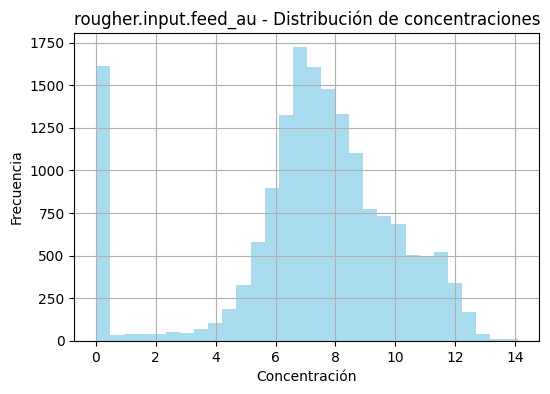

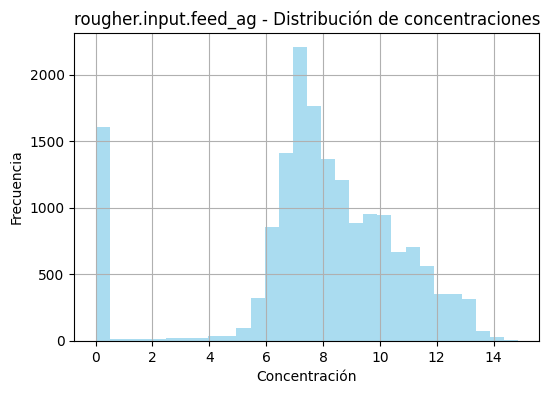

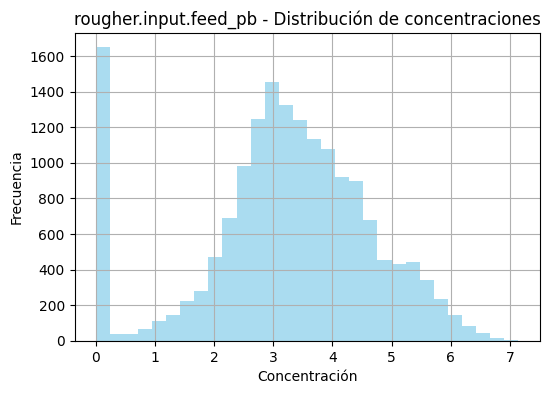

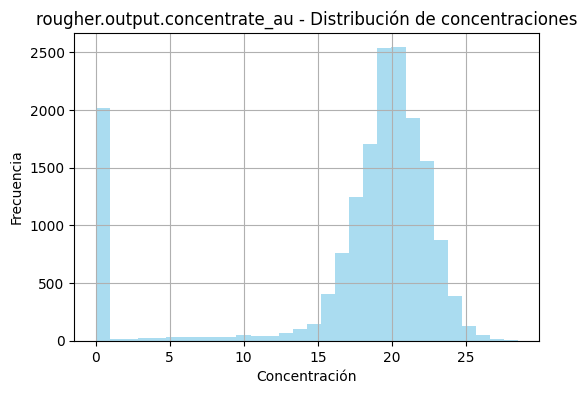

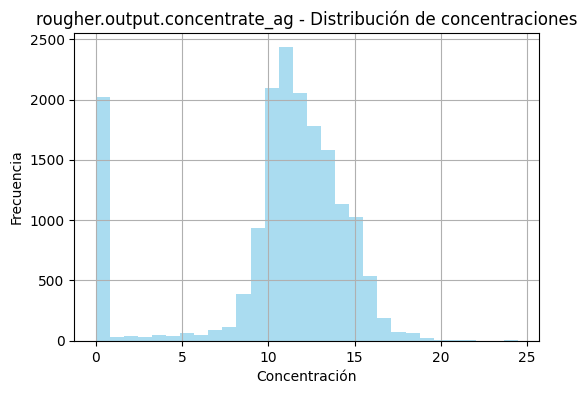

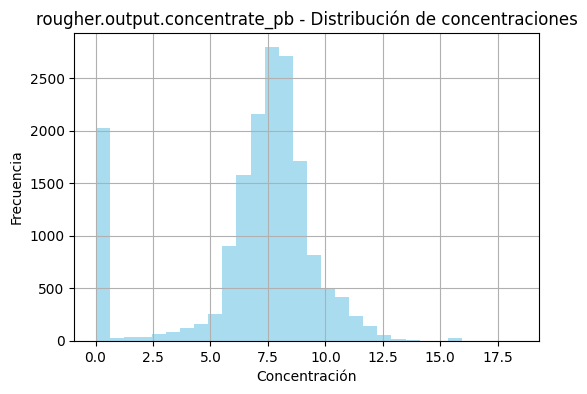

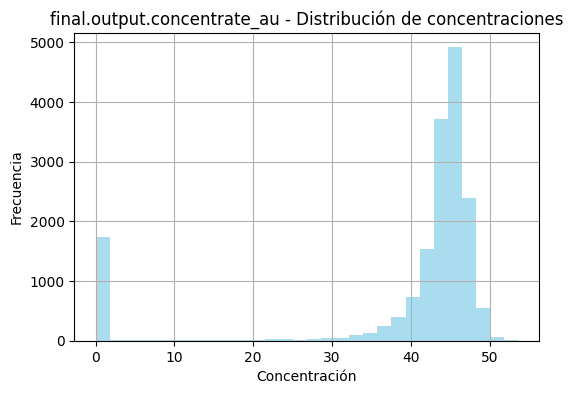

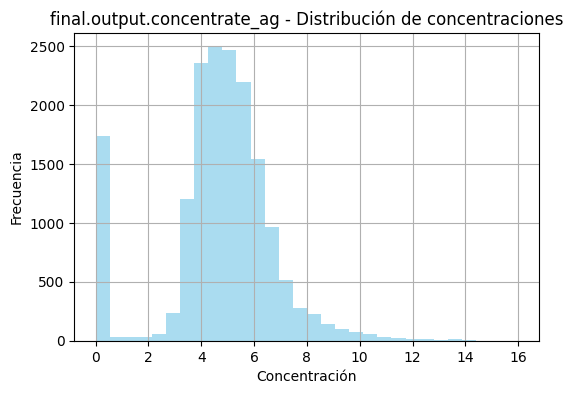

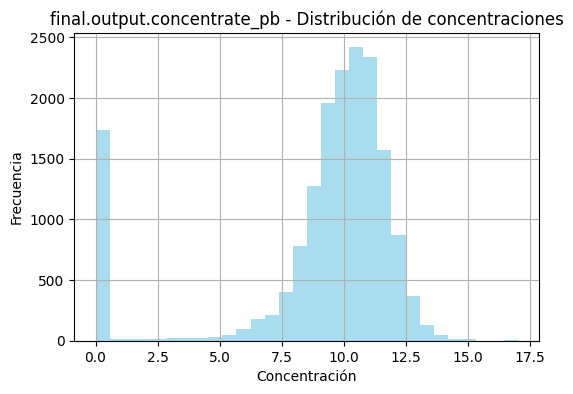

In [109]:
# Metales y etapas
metals = ['au', 'ag', 'pb']
stages = ['rougher.input.feed', 'rougher.output.concentrate', 'final.output.concentrate']

# Iterar y graficar
for stage in stages:
    for metal in metals:
        col = f'{stage}_{metal}'
        plt.figure(figsize=(6,4))
        train[col].hist(bins=30, alpha=0.7, color='skyblue')
        plt.title(f'{col} - Distribución de concentraciones')
        plt.xlabel('Concentración')
        plt.ylabel('Frecuencia')
        plt.show()


## Discusión: Cambios en la Concentración de Metales a lo Largo de las Etapas de Purificación

Se analizaron las distribuciones de concentración de los metales oro (Au), plata (Ag) y plomo (Pb) a lo largo de las distintas etapas del proceso de flotación y purificación. Los resultados muestran cómo el proceso industrial afecta la concentración de cada metal.

### Oro (Au)

- **Alimentación inicial (rougher.input.feed_au):**  
  Rango: 4 a 12 | Frecuencia máxima: ~1700  
  Representa la concentración de oro en la materia prima, mostrando baja concentración y variabilidad moderada.

- **Concentrado tras la flotación (rougher.output.concentrate_au):**  
  Rango: 15 a 25 | Frecuencia máxima: ~2500  
  Se observa un incremento significativo, reflejando la separación efectiva del oro del residuo (*rougher tails*).

- **Concentrado final tras purificación (final.output.concentrate_au):**  
  Rango: 40 a 50 | Frecuencia máxima: ~5000  
  La concentración alcanza su valor más alto, indicando que la purificación final logra concentrar el oro restante de manera eficiente y estable.

---

### Plata (Ag)

- **Alimentación inicial (rougher.input.feed_ag):**  
  Rango: 6 a 13 | Frecuencia máxima: ~2100  
  La concentración inicial es moderada, con una distribución relativamente amplia.

- **Concentrado tras la flotación (rougher.output.concentrate_ag):**  
  Rango: 9 a 16 | Frecuencia máxima: ~2400  
  Se observa un ligero incremento, mostrando que la flotación concentra parcialmente la plata junto con el oro.

- **Concentrado final tras purificación (final.output.concentrate_ag):**  
  Rango: 3 a 8 | Frecuencia máxima: ~2500  
  Curiosamente, la concentración final disminuye, lo que indica que la purificación está diseñada para maximizar la recuperación de oro y puede eliminar parte de la plata como subproducto.

---

### Plomo (Pb)

- **Alimentación inicial (rougher.input.feed_pb):**  
  Rango: 2 a 6 | Frecuencia máxima: ~1400  
  La concentración inicial de plomo es baja, reflejando su presencia limitada en la materia prima.

- **Concentrado tras la flotación (rougher.output.concentrate_pb):**  
  Rango: 5 a 10 | Frecuencia máxima: ~2700  
  Se observa un aumento, indicando que parte del plomo también se concentra durante la etapa de flotación.

- **Concentrado final tras purificación (final.output.concentrate_pb):**  
  Rango: 7.5 a 12 | Frecuencia máxima: ~2400  
  La concentración final de plomo continúa aumentando, aunque con menos frecuencia máxima que en la etapa intermedia, reflejando un proceso de purificación que retiene algo de plomo pero prioriza la extracción de oro.

---

### Conclusión General

- El oro (Au) muestra un **incremento progresivo constante**, alineado con el objetivo principal del proceso de purificación.  
- La plata (Ag) y el plomo (Pb) presentan comportamientos distintos: la plata disminuye en la etapa final, mientras que el plomo aumenta moderadamente, lo que refleja la selectividad del proceso hacia la recuperación de oro.  
- Las frecuencias máximas indican que la mayoría de las muestras se concentran en rangos específicos, sugiriendo **estabilidad y consistencia** en el funcionamiento de la planta industrial.  

> Este análisis confirma que el proceso de flotación y purificación está diseñado para optimizar la recuperación de oro, mientras que otros metales presentan comportamientos secundarios que deben ser monitoreados.

In [110]:
# Guardar los targets antes de dropear
target_rougher = train['rougher.output.recovery'].copy()
target_final = train['final.output.recovery'].copy()

# Identificar columnas que están en train pero NO en test
missing_cols = list(set(train.columns) - set(test.columns))
print("Columnas a dropear para evitar data leakage:", missing_cols)

# Crear conjunto de features seguro
# Dropeamos las columnas de missing_cols para evitar usar datos futuros
features = train.drop(columns=missing_cols)

# Verificar shapes
print("Shape de features:", features.shape)
print("Shape de target_rougher:", target_rougher.shape)
print("Shape de target_final:", target_final.shape)

Columnas a dropear para evitar data leakage: ['secondary_cleaner.output.tail_au', 'rougher.output.tail_pb', 'secondary_cleaner.output.tail_ag', 'primary_cleaner.output.concentrate_pb', 'final.output.concentrate_au', 'rougher.calculation.sulfate_to_au_concentrate', 'final.output.concentrate_ag', 'rougher.output.tail_ag', 'rougher.output.concentrate_pb', 'primary_cleaner.output.concentrate_ag', 'final.output.tail_au', 'final.output.concentrate_pb', 'primary_cleaner.output.tail_ag', 'final.output.tail_ag', 'secondary_cleaner.output.tail_pb', 'rougher.output.concentrate_ag', 'rougher.output.recovery', 'primary_cleaner.output.concentrate_au', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'primary_cleaner.output.tail_au', 'rougher.output.concentrate_au', 'primary_cleaner.output.concentrate_sol', 'final.output.tail_sol', 'rougher.output.concentrate_sol', 'secondary_cleaner.output.tail_sol', 'prima

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [110] alineaste las features de train con las de test eliminando columnas ausentes en test. Esta es una de las mejores decisiones del proyecto porque ataca directamente el riesgo de <i>data leakage</i>: si entrenas con variables de salida/cálculos que no existen al predecir, el score se vuelve artificialmente optimista. Tu enfoque deja el problema en un escenario realista.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
También en [110], separar primero los targets (<code>target_rougher</code> y <code>target_final</code>) antes de hacer <code>drop</code> es una práctica muy ordenada. Evita errores accidentales (como perder el target al filtrar columnas) y deja el pipeline más legible. Esa claridad es importante cuando después necesites replicar el proceso con el conjunto de prueba.
</div>

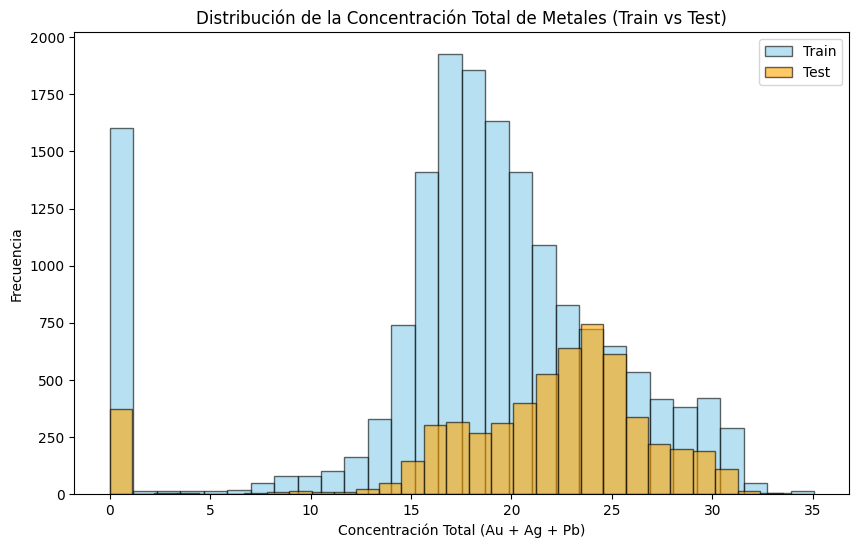

In [117]:
import matplotlib.pyplot as plt

# Calcular la concentración total de metales para train y test
total_train = (
    train['rougher.input.feed_au'] +
    train['rougher.input.feed_ag'] +
    train['rougher.input.feed_pb']
)

total_test = (
    test['rougher.input.feed_au'] +
    test['rougher.input.feed_ag'] +
    test['rougher.input.feed_pb']
)

# Graficar ambos histogramas en el mismo gráfico
plt.figure(figsize=(10,6))
plt.hist(total_train, bins=30, alpha=0.6, label='Train', color='skyblue', edgecolor='black')
plt.hist(total_test, bins=30, alpha=0.6, label='Test', color='orange', edgecolor='black')
plt.title('Distribución de la Concentración Total de Metales (Train vs Test)')
plt.xlabel('Concentración Total (Au + Ag + Pb)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En [117] comparas explícitamente train vs test para una variable agregada. Esto es una forma práctica de revisar “shift” de distribución: si los rangos fueran muy distintos, el modelo tendería a generalizar peor. Aunque es un análisis visual, es muy útil como semáforo rápido antes de entrenar.
</div>

El histograma de la concentración total de metales muestra que el rango de valores en el conjunto de entrenamiento y prueba es **similar**, lo que indica que el modelo podrá generalizar sobre los mismos intervalos. Aunque la frecuencia de ocurrencia de las observaciones difiere, esto no afecta la evaluación del modelo, ya que los rangos de las variables se mantienen consistentes.

## Modelado

In [112]:

features = features.drop(columns=['date'])
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
#  Función sMAPE
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred))
    diff = np.abs(y_true - y_pred) / denominator
    return 100 * np.mean(diff)

# Configuración del modelo

rf_model = RandomForestRegressor(n_estimators=100, random_state=123, n_jobs=-1)


#  Validación cruzada para Rougher

# cross_val_predict devuelve predicciones usando CV
pred_rougher = cross_val_predict(rf_model, features, target_rougher, cv=5)
smape_rougher = smape(target_rougher, pred_rougher)
print(f"sMAPE Rougher: {smape_rougher:.4f}%")


# 4️⃣ Validación cruzada para Final

pred_final = cross_val_predict(rf_model, features, target_final, cv=5)
smape_final = smape(target_final, pred_final)
print(f"sMAPE Final: {smape_final:.4f}%")


# 5️⃣ sMAPE total combinado

smape_total = 0.25 * smape_rougher + 0.75 * smape_final
print(f"sMAPE total combinado: {smape_total:.4f}%")


sMAPE Rougher: 9.5802%
sMAPE Final: 7.9274%
sMAPE total combinado: 8.3406%


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [112], para este proyecto normalmente se espera que la validación cruzada sea <i>temporal</i> (por ejemplo, <code>TimeSeriesSplit</code>) porque hay una columna de fecha y el proceso tiene dependencia en el tiempo. Con un <code>cv=5</code> estándar, podrías estar entrenando con “futuro” y evaluando con “pasado”, lo que hace la métrica más optimista de lo que sería en producción. Cambiar a un split temporal mantiene la evaluación más realista.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Tu función sMAPE en [112] necesita una protección contra división entre cero: si <code>|y_true| + |y_pred|</code> llega a 0, aparecerán <code>inf</code> o <code>nan</code> y la métrica dejaría de ser confiable. Una corrección típica es sumar un epsilon pequeño al denominador (por ejemplo <code>denominator = np.maximum(denominator, 1e-9)</code>). Esto no cambia el resultado cuando los valores son normales, pero vuelve el cálculo estable.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Elegir <code>RandomForestRegressor</code> en [112] es razonable para un primer modelo: maneja relaciones no lineales, suele funcionar bien con muchas variables numéricas y no exige escalado. Para un dataset industrial con múltiples sensores/estados, este tipo de modelo suele capturar interacciones útiles sin demasiada ingeniería de variables.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Además, usar <code>cross_val_predict</code> en [112] es una buena idea pedagógica: te permite obtener predicciones “fuera de fold” para todo el conjunto y calcular una métrica global de forma directa. Este enfoque se parece a una simulación de cómo el modelo se comportaría en datos no vistos, y es muy útil si luego quisieras graficar residuales o comparar predicción vs real.
</div>

## Conclusiones del Modelo de Predicción de Recuperación de Oro

Después de entrenar y evaluar el modelo de Random Forest para predecir la recuperación del oro en las distintas etapas del proceso, se obtuvieron los siguientes resultados:

- **sMAPE Rougher:** 9.58 %  
- **sMAPE Final:** 7.93 %  
- **sMAPE Total Combinado:** 8.34 %

Estos resultados permiten concluir:

1. **Mejor desempeño en la etapa final:** El modelo predice con mayor precisión la recuperación en la etapa final del proceso de purificación, como lo indica un sMAPE más bajo (7.93 %) en comparación con la etapa rougher (9.58 %).  
2. **Precisión general aceptable:** El sMAPE total combinado de 8.34 % refleja un desempeño adecuado para capturar las tendencias de recuperación del oro, especialmente considerando que la etapa final tiene mayor peso en la métrica combinada.  
3. **Posibles mejoras:** Aunque el modelo es razonablemente preciso, la predicción de la etapa rougher podría optimizarse ajustando hiperparámetros del modelo o evaluando otros algoritmos de machine learning.  

En resumen, el modelo proporciona predicciones útiles para monitorear y controlar el proceso de recuperación de oro, con un error relativo moderado que es más crítico en la etapa rougher que en la final.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Juan Manuel! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Revisaste estructura y tipos desde el inicio, lo que hace tu análisis más confiable<br>
• Trataste la fecha como variable temporal correctamente al cargar los datos<br>
• Validaste el target de recuperación con la fórmula, una práctica excelente de control de calidad<br>
• Interpretaste con precisión el error numérico extremadamente pequeño (precisión de punto flotante)<br>
• Aplicaste una imputación coherente con el contexto temporal del proceso (ffill)<br>
• Construiste EDA alineado al proceso (feed → rougher → final) para validar consistencia industrial<br>
• Usaste una variable agregada (Au+Ag+Pb) para detectar anomalías de manera simple y efectiva<br>
• Protegiste tu notebook contra fallos por columnas faltantes al graficar/sumar features<br>
• Evitaste data leakage al alinear train con test antes de entrenar<br>
• Evaluaste el modelo con una métrica y un esquema de predicción por CV que permite diagnóstico global<br>
<br>
¡Felicidades!
</div>